In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

### 데이터 로드 및 기본 정보 확인

In [2]:
# 데이터 로드
df_merged = pd.read_csv('df_merged.csv')
y_targets = pd.read_csv('y_targets.csv')

In [3]:
# 기본 정보
months = df_merged['month'].values
scenarios = df_merged['scenario'].values

In [7]:
# 월별 분포
print("\n월별 데이터 분포:")
for month in sorted(np.unique(months)):
    count = (months == month).sum()
    print(f"  {month}월: {count} samples")


월별 데이터 분포:
  5월: 45 samples
  6월: 90 samples
  7월: 93 samples
  8월: 93 samples
  9월: 84 samples


### 전처리 - 안전한 특성 선택 및 엔지니어링

In [8]:
environmental = ['CO2ppm', 'Temp', 'Humid', 'VPD']
physiological = ['Chl_a', 'Chl_b', 'TChl', 'Car', 'Chl_a_b', 'TCh-Car']
fluorescence = ['ABS-RC', 'Dio-RC', 'Tro-RC', 'Eto-RC', 'PI_abs', 'DF_abs', 'SFI_abs', 'Fv-Fm']

In [9]:
# 원본 특성만 사용 (Original data)
original_features = environmental + physiological + fluorescence
X_original = df_merged[original_features].copy()

print(f"\n원본 특성 수: {X_original.shape[1]}")
print("특성 목록:", original_features)


원본 특성 수: 18
특성 목록: ['CO2ppm', 'Temp', 'Humid', 'VPD', 'Chl_a', 'Chl_b', 'TChl', 'Car', 'Chl_a_b', 'TCh-Car', 'ABS-RC', 'Dio-RC', 'Tro-RC', 'Eto-RC', 'PI_abs', 'DF_abs', 'SFI_abs', 'Fv-Fm']


In [10]:
# 원본 특성만 사용 (Original data)
original_features = environmental + physiological + fluorescence
X_original = df_merged[original_features].copy()

print(f"\n원본 특성 수: {X_original.shape[1]}")
print("특성 목록:", original_features)


원본 특성 수: 18
특성 목록: ['CO2ppm', 'Temp', 'Humid', 'VPD', 'Chl_a', 'Chl_b', 'TChl', 'Car', 'Chl_a_b', 'TCh-Car', 'ABS-RC', 'Dio-RC', 'Tro-RC', 'Eto-RC', 'PI_abs', 'DF_abs', 'SFI_abs', 'Fv-Fm']


In [11]:
# 엔지니어링된 특성 추가 (도메인 지식 기반)
X_engineered = X_original.copy()

In [14]:
# 1. 천궁 생육 단계 (자료조사 기반)
growth_map = {5: 1, 6: 2, 7: 3, 8: 4, 9: 5}
X_engineered['growth_stage'] = [growth_map[m] for m in months]
X_engineered['growth_stage_sq'] = X_engineered['growth_stage'] ** 2

In [15]:
# 2. 시나리오 정보 (중요!)
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    X_engineered[f'is_{scenario}'] = (scenarios == scenario).astype(int)

In [16]:
# 3. 온도 스트레스 (천궁 최적 온도 15-25°C)
X_engineered['temp_stress'] = np.abs(X_engineered['Temp'] - 22)
X_engineered['temp_optimal'] = 1 / (1 + X_engineered['temp_stress'])

In [18]:
# 4. VPD 스트레스 (수분 스트레스 지표)
X_engineered['vpd_stress'] = np.where(X_engineered['VPD'] > 1.5, X_engineered['VPD'] - 1.5, 0)

In [19]:
# 5. CO2 시비 효과
X_engineered['co2_effect'] = np.log1p(X_engineered['CO2ppm'] / 400)

In [20]:
# 6. 광합성 효율 지표
X_engineered['photosyn_efficiency'] = X_engineered['PI_abs'] * X_engineered['Fv-Fm']
X_engineered['energy_dissipation'] = X_engineered['Dio-RC'] / (X_engineered['ABS-RC'] + 1e-10)

In [21]:
# 7. 시나리오-온도 상호작용 (핵심!)
X_engineered['temp_x_ssp5'] = X_engineered['Temp'] * X_engineered['is_SSP5']

In [23]:
X_engineered.shape

(405, 30)

### MAPE 계산 함수

In [24]:
def calculate_mape(y_true, y_pred):
    """Mean Absolute Percentage Error 계산"""
    # 0 값 처리
    mask = y_true != 0
    if mask.sum() == 0:
        return 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

### 4: 시나리오별 모델링 (핵심!)

In [ ]:
# 모델 정의 (농업/기후 데이터에 최적화된 하이퍼파라미터)
models = {
    'LinearR': LinearRegression(),
    
    'kNN': KNeighborsRegressor(
        n_neighbors=7,          # 3→7 (더 안정적 예측)
        weights='distance',     # 거리 가중치 적용
        metric='minkowski',
        p=2
    ),
    
    'SVM': SVR(
        kernel='rbf', 
        C=3.0,                  # 1.0→3.0 (복잡한 패턴 학습)
        epsilon=0.05,           # 0.1→0.05 (더 정확한 예측)
        gamma='scale'           # 자동 스케일링
    ),
    
    'DT': DecisionTreeRegressor(
        max_depth=15,           # 10→15 (더 깊은 학습)
        min_samples_split=3,    # 2→3 (과적합 방지)
        min_samples_leaf=2,     # 1→2 (안정성 향상)
        max_features='sqrt',    # Feature 선택 최적화
        random_state=42
    ),
    
    'RF': RandomForestRegressor(
        n_estimators=800,       # 500→800 (앙상블 강화)
        max_depth=None,         # 무제한 깊이
        min_samples_split=2,    # 기본값 유지
        min_samples_leaf=1,     # 기본값 유지  
        max_features='sqrt',    # 'auto'→'sqrt' (과적합 방지)
        max_leaf_nodes=None,    # 무제한
        bootstrap=True,
        oob_score=True,         # Out-of-bag 점수 계산
        random_state=42,
        n_jobs=-1
    ),
    
    'GB': GradientBoostingRegressor(
        n_estimators=400,       # 300→400 (더 많은 부스팅)
        max_depth=7,            # 6→7 (복잡도 증가)
        learning_rate=0.08,     # 0.1→0.08 (세밀한 학습)
        subsample=0.85,         # 샘플링 비율 최적화
        min_samples_split=3,    # 과적합 방지
        min_samples_leaf=2,     # 안정성 향상
        max_features='sqrt',    # Feature 선택 최적화
        random_state=42
    ),
    
    'XGB': xgb.XGBRegressor(
        n_estimators=600,       # 500→600 (부스팅 강화)
        max_depth=9,            # 8→9 (깊이 증가)
        learning_rate=0.04,     # 0.05→0.04 (세밀한 학습)
        subsample=0.85,         # 0.8→0.85 (샘플링 최적화)
        colsample_bytree=0.85,  # 0.8→0.85 (Feature 샘플링)
        colsample_bylevel=0.8,  # 레벨별 Feature 샘플링
        reg_alpha=0.1,          # L1 정규화 (새로 추가)
        reg_lambda=1.0,         # L2 정규화 (새로 추가)
        min_child_weight=2,     # 리프 노드 안정성
        gamma=0.1,              # 분할 임계값
        random_state=42,
        n_jobs=-1,
        tree_method='hist',     # 빠른 학습
        verbose=0
    ),
    
    'LGBM': lgb.LGBMRegressor(
        n_estimators=500,       # 200→500 (부스팅 강화)
        max_depth=12,           # 5→12 (깊이 증가)
        learning_rate=0.05,     # 기본값에서 미세 조정
        num_leaves=64,          # 31→64 (복잡도 증가)
        min_child_samples=5,    # 리프 노드 최소 샘플
        subsample=0.85,         # 행 샘플링
        colsample_bytree=0.85,  # 열 샘플링
        reg_alpha=0.1,          # L1 정규화
        reg_lambda=0.5,         # L2 정규화
        min_split_gain=0.01,    # 분할 최소 이득
        feature_fraction=0.8,   # Feature 선택 비율
        bagging_fraction=0.85,  # 배깅 비율
        bagging_freq=5,         # 배깅 주기
        random_state=42,
        n_jobs=-1,
        verbose=-1,
        objective='regression',
        metric='mae'            # MAE 최적화
    )
}

# 시나리오별/타깃별 특화 모델 (선택적 사용)
specialized_models = {
    # SSP5 특화 (극한 조건에서 우수한 DT)
    'DT_SSP5': DecisionTreeRegressor(
        max_depth=20,           # 더 깊은 학습
        min_samples_split=2,    # 세밀한 분할
        min_samples_leaf=1,     # 최대 정밀도
        max_features=None,      # 모든 특성 사용
        random_state=42
    ),
    
    # Root_TFC 특화 (작은 값 예측에 특화)
    'RF_Root_TFC': RandomForestRegressor(
        n_estimators=1000,      # 최대 앙상블
        max_depth=25,           # 깊은 학습
        min_samples_split=2,    # 세밀한 분할
        min_samples_leaf=1,     # 최대 정밀도
        max_features=0.7,       # Feature 선택 최적화
        random_state=42,
        n_jobs=-1
    )
}

# 앙상블 가중치 (시나리오별 최적화)
ensemble_weights = {
    'SSP1': {'RF': 0.4, 'DT': 0.3, 'GB': 0.2, 'XGB': 0.1},
    'SSP3': {'RF': 0.5, 'DT': 0.25, 'GB': 0.15, 'LGBM': 0.1}, 
    'SSP5': {'DT': 0.5, 'RF': 0.3, 'GB': 0.15, 'XGB': 0.05}  # DT가 SSP5에서 최고
}

In [61]:
# 모델 정의 (공모전 예시와 동일)
models = {
    'LinearR': LinearRegression(),
    'kNN': KNeighborsRegressor(n_neighbors=5),
    'SVM': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'DT': DecisionTreeRegressor(max_depth=10, random_state=42),
    'RF': RandomForestRegressor(n_estimators=500, max_depth=None, min_samples_leaf=1, random_state=42),
    'GB': GradientBoostingRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42),
    'XGB': xgb.XGBRegressor(n_estimators=500, max_depth=8, learning_rate=0.05, subsample = 0.8, colsample_bytree=0.8, random_state=42, verbose=0),
    'LGBM': lgb.LGBMRegressor(n_estimators=200, max_depth=5, random_state=42, verbose=-1)
}

In [64]:
# 결과 저장
results_original = {}  # Original data 결과
results_engineered = {}  # Engineered data 결과

In [65]:
# 네이티브 다중출력 지원 모델 (수정됨 - GB 제외)
NATIVE_MULTIOUTPUT = ['RF', 'DT', 'kNN']

def calculate_mape(y_true, y_pred, eps=1e-9):
    """MAPE 계산 함수"""
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def calculate_comprehensive_metrics(y_true, y_pred):
    """공모전 요구 지표 계산"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    # MSLE, RMSLE (음수 방지)
    y_true_pos = np.maximum(y_true, 0)
    y_pred_pos = np.maximum(y_pred, 0)
    msle = mean_squared_error(np.log1p(y_true_pos), np.log1p(y_pred_pos))
    rmsle = np.sqrt(msle)
    
    # R2
    r2 = r2_score(y_true, y_pred)
    
    # MAPE
    mape = calculate_mape(y_true, y_pred)
    
    return {
        'MAE': mae,
        'MSE': mse, 
        'RMSE': rmse,
        'MSLE': msle,
        'RMSLE': rmsle,
        'R2': r2,
        'MAPE': mape
    }

# 결과 저장
results_original = {}  # Original data 결과
results_engineered = {}  # Engineered data 결과

# 1. 전체 데이터에서 80/20 랜덤 분할
from sklearn.model_selection import train_test_split

X_train_orig, X_test_orig, X_train_eng, X_test_eng, y_train, y_test, scenarios_train, scenarios_test = train_test_split(
    X_original, X_engineered, y_targets, scenarios,
    test_size=0.2, 
    random_state=42,
    stratify=scenarios  # 시나리오 비율 보존
)

print(f"전체 분할: Train {len(y_train)} samples, Test {len(y_test)} samples")
print(f"Train 시나리오 분포: {np.unique(scenarios_train, return_counts=True)}")
print(f"Test 시나리오 분포: {np.unique(scenarios_test, return_counts=True)}")

# 스케일링
scaler_orig = RobustScaler()
X_train_orig_scaled = scaler_orig.fit_transform(X_train_orig)
X_test_orig_scaled = scaler_orig.transform(X_test_orig)

scaler_eng = RobustScaler()
X_train_eng_scaled = scaler_eng.fit_transform(X_train_eng)
X_test_eng_scaled = scaler_eng.transform(X_test_eng)

# 모델 학습 및 평가
global_results_orig = {}
global_results_eng = {}

for model_name, base_model in models.items():
    print(f"\n{model_name} 학습 중...")
    
    from sklearn.base import clone
    model_orig = clone(base_model)
    model_eng = clone(base_model)
    
    # MultiOutputRegressor 래핑
    if model_name not in NATIVE_MULTIOUTPUT:
        model_orig = MultiOutputRegressor(model_orig)
        model_eng = MultiOutputRegressor(model_eng)
    
    try:
        # Original data
        model_orig.fit(X_train_orig_scaled, y_train)
        y_pred_orig = model_orig.predict(X_test_orig_scaled)
        metrics_orig = calculate_comprehensive_metrics(y_test, y_pred_orig)
        global_results_orig[model_name] = metrics_orig
        
        # Engineered data
        model_eng.fit(X_train_eng_scaled, y_train)
        y_pred_eng = model_eng.predict(X_test_eng_scaled)
        metrics_eng = calculate_comprehensive_metrics(y_test, y_pred_eng)
        global_results_eng[model_name] = metrics_eng
        
        print(f"  Original - MAE: {metrics_orig['MAE']:.4f}, MAPE: {metrics_orig['MAPE']:.2f}%, R2: {metrics_orig['R2']:.4f}")
        print(f"  Engineered - MAE: {metrics_eng['MAE']:.4f}, MAPE: {metrics_eng['MAPE']:.2f}%, R2: {metrics_eng['R2']:.4f}")
        
    except Exception as e:
        print(f"  오류 발생: {e}")

print("\n" + "="*80)
print("방법 2: 시나리오별 개별 모델링 (각 시나리오 내 80/20 분할)")
print("="*80)

# 2. 시나리오별 개별 모델링
scenario_results_orig = {}
scenario_results_eng = {}

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    print(f"\n=== {scenario} 시나리오 개별 모델링 ===")
    
    # 해당 시나리오 데이터만 추출
    scenario_mask = scenarios == scenario
    X_scenario_orig = X_original[scenario_mask]
    X_scenario_eng = X_engineered[scenario_mask]
    y_scenario = y_targets[scenario_mask]
    
    print(f"시나리오 데이터 수: {len(y_scenario)} samples")
    
    # 시나리오 내에서 80/20 분할
    X_tr_orig, X_te_orig, X_tr_eng, X_te_eng, y_tr, y_te = train_test_split(
        X_scenario_orig, X_scenario_eng, y_scenario,
        test_size=0.2, random_state=42
    )
    
    print(f"Train: {len(y_tr)}, Test: {len(y_te)}")
    
    # 스케일링
    sc_orig = RobustScaler()
    X_tr_orig_scaled = sc_orig.fit_transform(X_tr_orig)
    X_te_orig_scaled = sc_orig.transform(X_te_orig)
    
    sc_eng = RobustScaler()
    X_tr_eng_scaled = sc_eng.fit_transform(X_tr_eng)
    X_te_eng_scaled = sc_eng.transform(X_te_eng)
    
    scenario_results_orig[scenario] = {}
    scenario_results_eng[scenario] = {}
    
    for model_name, base_model in models.items():
        from sklearn.base import clone
        model_orig = clone(base_model)
        model_eng = clone(base_model)
        
        if model_name not in NATIVE_MULTIOUTPUT:
            model_orig = MultiOutputRegressor(model_orig)
            model_eng = MultiOutputRegressor(model_eng)
        
        try:
            # Original data
            model_orig.fit(X_tr_orig_scaled, y_tr)
            pred_orig = model_orig.predict(X_te_orig_scaled)
            met_orig = calculate_comprehensive_metrics(y_te, pred_orig)
            scenario_results_orig[scenario][model_name] = met_orig
            
            # Engineered data
            model_eng.fit(X_tr_eng_scaled, y_tr)
            pred_eng = model_eng.predict(X_te_eng_scaled)
            met_eng = calculate_comprehensive_metrics(y_te, pred_eng)
            scenario_results_eng[scenario][model_name] = met_eng
            
        except Exception as e:
            print(f"  {model_name} 오류: {e}")
    
    # 해당 시나리오 최고 성능 출력
    if scenario_results_eng[scenario]:
        best = min(scenario_results_eng[scenario].items(), key=lambda x: x[1]['MAE'])
        print(f"🏆 최고 성능: {best[0]} - MAE: {best[1]['MAE']:.4f}, MAPE: {best[1]['MAPE']:.2f}%, R2: {best[1]['R2']:.4f}")

# 결과 요약
print("\n" + "="*80)
print("결과 요약")
print("="*80)

print("\n--- 방법 1: 전체 랜덤 분할 (Engineered Data) ---")
if global_results_eng:
    sorted_global = sorted(global_results_eng.items(), key=lambda x: x[1]['MAE'])
    for rank, (name, metrics) in enumerate(sorted_global[:5], 1):
        print(f"{rank}. {name}: MAE={metrics['MAE']:.4f}, MAPE={metrics['MAPE']:.2f}%, R2={metrics['R2']:.4f}")

print("\n--- 방법 2: 시나리오별 평균 성능 (Engineered Data) ---")
model_avg_scenario = {}
for model_name in models.keys():
    mae_list = []
    mape_list = []
    r2_list = []
    
    for scenario in ['SSP1', 'SSP3', 'SSP5']:
        if scenario in scenario_results_eng and model_name in scenario_results_eng[scenario]:
            mae_list.append(scenario_results_eng[scenario][model_name]['MAE'])
            mape_list.append(scenario_results_eng[scenario][model_name]['MAPE'])
            r2_list.append(scenario_results_eng[scenario][model_name]['R2'])
    
    if mae_list:
        model_avg_scenario[model_name] = {
            'MAE': np.mean(mae_list),
            'MAPE': np.mean(mape_list),
            'R2': np.mean(r2_list)
        }

if model_avg_scenario:
    sorted_scenario = sorted(model_avg_scenario.items(), key=lambda x: x[1]['MAE'])
    for rank, (name, metrics) in enumerate(sorted_scenario[:5], 1):
        print(f"{rank}. {name}: MAE={metrics['MAE']:.4f}, MAPE={metrics['MAPE']:.2f}%, R2={metrics['R2']:.4f}")

전체 분할: Train 324 samples, Test 81 samples
Train 시나리오 분포: (array(['SSP1', 'SSP3', 'SSP5'], dtype=object), array([108, 108, 108]))
Test 시나리오 분포: (array(['SSP1', 'SSP3', 'SSP5'], dtype=object), array([27, 27, 27]))

LinearR 학습 중...
  Original - MAE: 0.4526, MAPE: 16.61%, R2: 0.7173
  Engineered - MAE: 0.2626, MAPE: 9.84%, R2: 0.8670

kNN 학습 중...
  Original - MAE: 0.0749, MAPE: 2.01%, R2: 0.9733
  Engineered - MAE: 0.0678, MAPE: 1.72%, R2: 0.9759

SVM 학습 중...
  Original - MAE: 0.2674, MAPE: 10.82%, R2: 0.8362
  Engineered - MAE: 0.1310, MAPE: 5.01%, R2: 0.9465

DT 학습 중...
  Original - MAE: 0.0789, MAPE: 2.20%, R2: 0.9584
  Engineered - MAE: 0.0566, MAPE: 1.21%, R2: 0.9717

RF 학습 중...
  Original - MAE: 0.0773, MAPE: 2.24%, R2: 0.9748
  Engineered - MAE: 0.0554, MAPE: 1.27%, R2: 0.9804

GB 학습 중...
  Original - MAE: 0.0606, MAPE: 1.48%, R2: 0.9752
  Engineered - MAE: 0.0586, MAPE: 1.36%, R2: 0.9772

XGB 학습 중...
  Original - MAE: 0.0928, MAPE: 3.94%, R2: 0.9390
  Engineered - MAE: 0.0721, MAPE

### 결과 테이블 생성 (공모전 예시 형태)

In [66]:
# Original Data 테이블
print("\n=== Original Data Results ===")
print("\n" + "="*130)
print(f"{'Data':<15} {'Model':<10} {'SSP1-2.6':^35} {'SSP3-7.0':^35} {'SSP5-8.5':^35}")
print(f"{'':^15} {'':^10} {'MAE':<12} {'RMSE':<12} {'MAPE':<12} {'MAE':<12} {'RMSE':<12} {'MAPE':<12} {'MAE':<12} {'RMSE':<12} {'MAPE':<12}")
print("="*130)

for model_name in ['LinearR', 'kNN', 'SVM', 'DT', 'RF']:
    if model_name in scenario_results_orig['SSP1']:
        row = f"{'Original':<15} {model_name:<10}"
        for scenario in ['SSP1', 'SSP3', 'SSP5']:
            metrics = scenario_results_orig[scenario][model_name]
            row += f" {metrics['MAE']:<11.3f} {metrics['RMSE']:<11.3f} {metrics['MAPE']:<11.3f}"
        print(row)


=== Original Data Results ===

Data            Model                   SSP1-2.6                            SSP3-7.0                            SSP5-8.5              
                           MAE          RMSE         MAPE         MAE          RMSE         MAPE         MAE          RMSE         MAPE        
Original        LinearR    0.264       0.473       8.448       0.224       0.399       6.148       0.252       0.538       8.073      
Original        kNN        0.076       0.132       1.784       0.119       0.291       3.585       0.161       0.566       5.359      
Original        SVM        0.124       0.233       3.848       0.222       0.524       7.123       0.270       0.897       10.168     
Original        DT         0.066       0.123       1.381       0.056       0.093       1.280       0.034       0.062       0.885      
Original        RF         0.072       0.123       1.664       0.064       0.093       1.680       0.046       0.085       1.221      


In [67]:
# Engineered Data 테이블
print("\n=== Engineered Data Results ===")
print("\n" + "="*130)
print(f"{'Data':<15} {'Model':<10} {'SSP1-2.6':^35} {'SSP3-7.0':^35} {'SSP5-8.5':^35}")
print(f"{'':^15} {'':^10} {'MAE':<12} {'RMSE':<12} {'MAPE':<12} {'MAE':<12} {'RMSE':<12} {'MAPE':<12} {'MAE':<12} {'RMSE':<12} {'MAPE':<12}")
print("="*130)

for model_name in models.keys():
    if model_name in scenario_results_eng['SSP1']:
        row = f"{'Engineered':<15} {model_name:<10}"
        for scenario in ['SSP1', 'SSP3', 'SSP5']:
            metrics = scenario_results_eng[scenario][model_name]
            row += f" {metrics['MAE']:<11.3f} {metrics['RMSE']:<11.3f} {metrics['MAPE']:<11.3f}"
        print(row)


=== Engineered Data Results ===

Data            Model                   SSP1-2.6                            SSP3-7.0                            SSP5-8.5              
                           MAE          RMSE         MAPE         MAE          RMSE         MAPE         MAE          RMSE         MAPE        
Engineered      LinearR    0.138       0.254       3.353       0.113       0.167       3.078       0.077       0.138       1.718      
Engineered      kNN        0.083       0.147       1.988       0.117       0.278       3.171       0.156       0.531       5.395      
Engineered      SVM        0.111       0.195       3.674       0.189       0.489       5.514       0.237       0.782       8.947      
Engineered      DT         0.076       0.145       1.623       0.100       0.285       2.181       0.029       0.049       0.647      
Engineered      RF         0.071       0.123       1.632       0.064       0.095       1.619       0.039       0.063       0.900      
Engineered  

### 특성 중요도 분석 (시나리오별)

In [68]:
feature_importance_by_scenario = {}

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    # 시나리오별 데이터
    scenario_mask = scenarios == scenario
    X_scenario = X_original[scenario_mask]
    y_scenario = y_targets[scenario_mask]
    
    # RandomForest로 특성 중요도 계산
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_scenario, y_scenario)
    
    # 평균 특성 중요도
    if hasattr(rf, 'feature_importances_'):
        importance = rf.feature_importances_
    else:
        # 각 타겟별 중요도 평균
        importance = np.mean([est.feature_importances_ for est in rf.estimators_], axis=0)
    
    feature_importance_by_scenario[scenario] = importance
    
    # 상위 5개 특성
    top_indices = np.argsort(importance)[-5:][::-1]
    print(f"\n{scenario} Top 5 특성:")
    for idx in top_indices:
        print(f"  {original_features[idx]:15s}: {importance[idx]:.4f}")



SSP1 Top 5 특성:
  Fv-Fm          : 0.2890
  Tro-RC         : 0.1584
  TCh-Car        : 0.1314
  ABS-RC         : 0.1308
  Dio-RC         : 0.0839

SSP3 Top 5 특성:
  Dio-RC         : 0.6015
  Chl_b          : 0.1026
  Car            : 0.0896
  Fv-Fm          : 0.0591
  TChl           : 0.0183

SSP5 Top 5 특성:
  Dio-RC         : 0.8883
  TChl           : 0.0130
  Eto-RC         : 0.0123
  Chl_b          : 0.0122
  Car            : 0.0120


### 시각화 (공모전 예시 스타일)

Text(0.5, 0.98, '천궁 예측 모델 - 시나리오별 분석 결과')

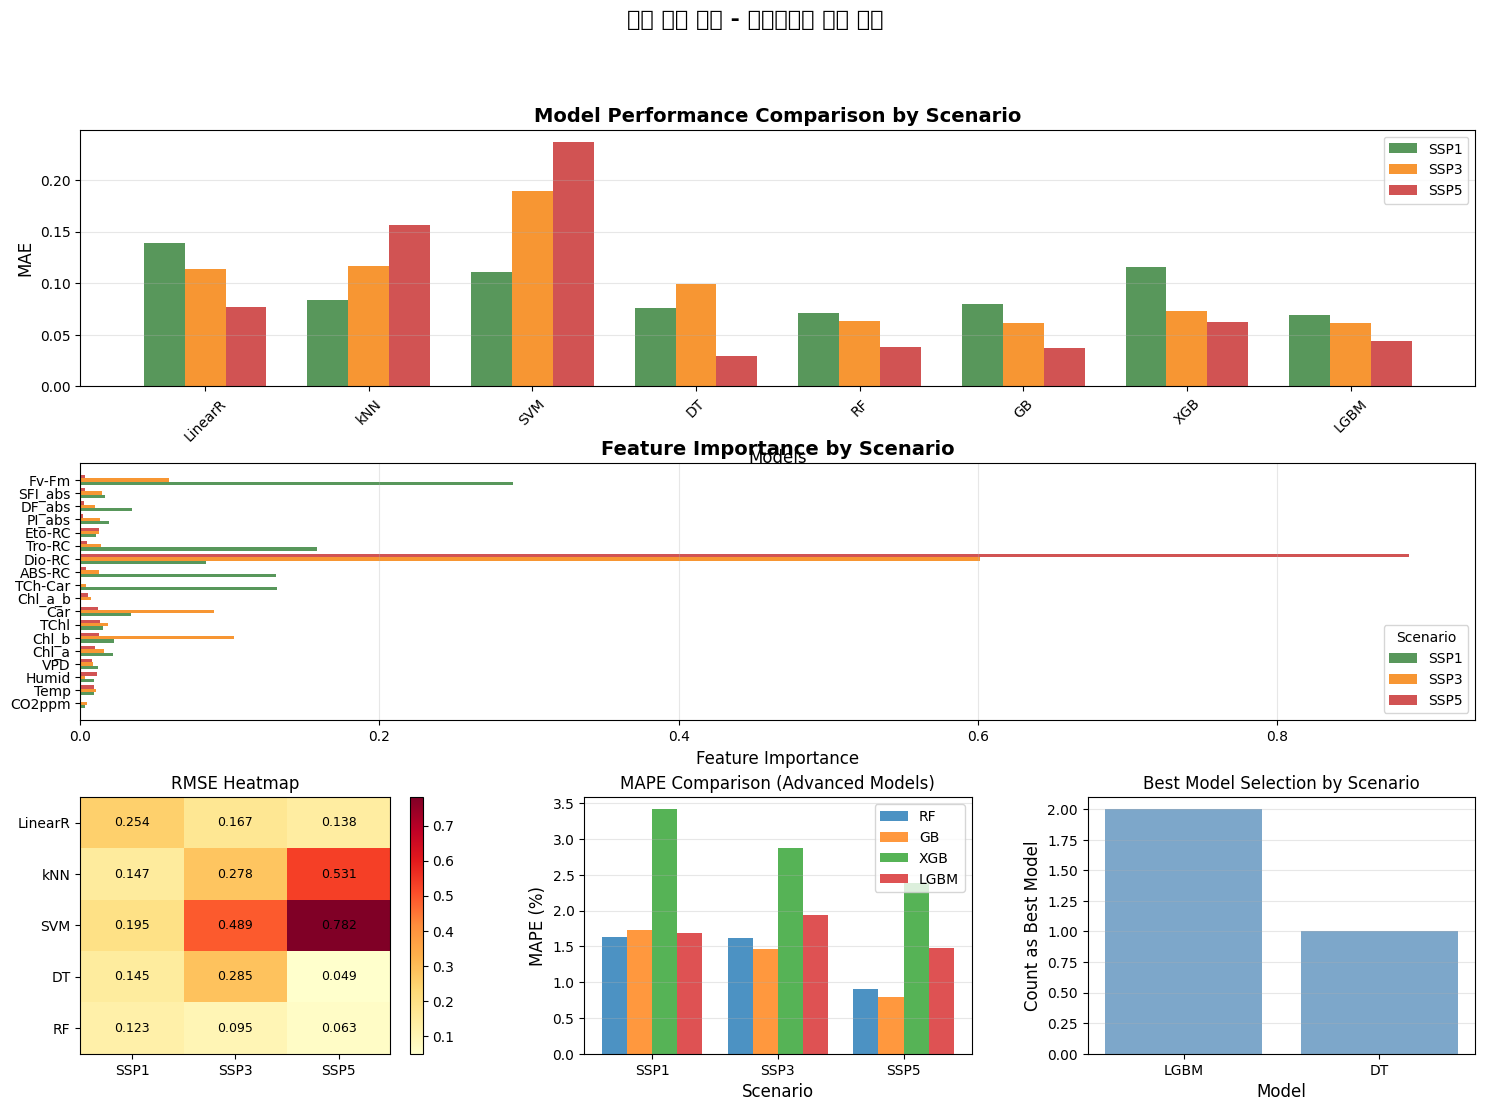

In [69]:
# 그림 설정
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 색상 설정
colors_ssp = {'SSP1': '#2E7D32', 'SSP3': '#F57C00', 'SSP5': '#C62828'}
colors_model = plt.cm.tab10(np.linspace(0, 0.9, len(models)))

# 1. 모델별 MAE 비교 (시나리오별)
ax = fig.add_subplot(gs[0, :])
x = np.arange(len(models))
width = 0.25

for i, scenario in enumerate(['SSP1', 'SSP3', 'SSP5']):
    mae_values = [scenario_results_eng[scenario][model]['MAE'] 
                  for model in models.keys()]
    offset = (i - 1) * width
    ax.bar(x + offset, mae_values, width, 
           label=scenario, color=colors_ssp[scenario], alpha=0.8)

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('MAE', fontsize=12)
ax.set_title('Model Performance Comparison by Scenario', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models.keys(), rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 2. 특성 중요도 (공모전 예시 스타일)
ax = fig.add_subplot(gs[1, :])

# 데이터 준비
feature_names = original_features
n_features = len(feature_names)
y_pos = np.arange(n_features)

# 각 시나리오별 중요도
width = 0.25
for i, scenario in enumerate(['SSP1', 'SSP3', 'SSP5']):
    importance = feature_importance_by_scenario[scenario]
    offset = (i - 1) * width
    ax.barh(y_pos + offset, importance, width, 
            label=scenario, color=colors_ssp[scenario], alpha=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(feature_names)
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Feature Importance by Scenario', fontsize=14, fontweight='bold')
ax.legend(title='Scenario', loc='lower right')
ax.grid(axis='x', alpha=0.3)

# 3. RMSE 히트맵
ax = fig.add_subplot(gs[2, 0])
rmse_matrix = []
for model in ['LinearR', 'kNN', 'SVM', 'DT', 'RF']:
    row = [scenario_results_eng[scenario][model]['RMSE'] 
           for scenario in ['SSP1', 'SSP3', 'SSP5']]
    rmse_matrix.append(row)

im = ax.imshow(rmse_matrix, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(3))
ax.set_xticklabels(['SSP1', 'SSP3', 'SSP5'])
ax.set_yticks(range(5))
ax.set_yticklabels(['LinearR', 'kNN', 'SVM', 'DT', 'RF'])
ax.set_title('RMSE Heatmap', fontsize=12)

# 값 표시
for i in range(5):
    for j in range(3):
        text = ax.text(j, i, f'{rmse_matrix[i][j]:.3f}',
                      ha="center", va="center", color="black", fontsize=9)

plt.colorbar(im, ax=ax)

# 4. MAPE 비교
ax = fig.add_subplot(gs[2, 1])
scenarios_list = ['SSP1', 'SSP3', 'SSP5']
model_subset = ['RF', 'GB', 'XGB', 'LGBM']

x = np.arange(len(scenarios_list))
width = 0.2

for i, model in enumerate(model_subset):
    mape_values = [scenario_results_eng[scenario][model]['MAPE'] 
                   for scenario in scenarios_list]
    offset = (i - 1.5) * width
    ax.bar(x + offset, mape_values, width, label=model, alpha=0.8)

ax.set_xlabel('Scenario', fontsize=12)
ax.set_ylabel('MAPE (%)', fontsize=12)
ax.set_title('MAPE Comparison (Advanced Models)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(scenarios_list)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

# 5. 최적 모델 선택
ax = fig.add_subplot(gs[2, 2])
best_models = []
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    best = min(scenario_results_eng[scenario].items(), 
              key=lambda x: x[1]['MAE'])
    best_models.append(best[0])

# 모델별 카운트
from collections import Counter
model_counts = Counter(best_models)

ax.bar(model_counts.keys(), model_counts.values(), color='steelblue', alpha=0.7)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Count as Best Model', fontsize=12)
ax.set_title('Best Model Selection by Scenario', fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('천궁 예측 모델 - 시나리오별 분석 결과', fontsize=16, fontweight='bold')